# Anomaly Detection in ZTF Astronomical Transients — TNS-Confirmed Objects Only
*AppliedML2026 – Final Project*

**Konstantinos Plainos**   |   University of Copenhagen, June 2026

---

This variant of the pipeline restricts the dataset to the **5,198 objects with a
spectroscopic classification from the Transient Name Server (TNS)**.
All labels are therefore spectroscopically confirmed — the strongest possible ground truth.

The autoencoder is trained on TNS-confirmed normal objects (SN + AGN + VS),
and rare types (TDE, SLSN-I, SLSN-II) serve as the known anomaly validation set.

**Pipeline:**
1. Load data → keep only TNS-confirmed objects → drop artifact classes
2. Automatic feature selection via Pearson correlation filter
3. Winsorise + impute + z-score scale
4. Autoencoder trained on normal objects only (SN + AGN + VS), 5-fold CV
5. Score every object by out-of-fold reconstruction error
6. Validate against specific TNS rare types (TDE, SLSN-I, SLSN-II)
7. Inspect top anomaly lightcurves

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os as _os

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold

import umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  device: {DEVICE}")

I0000 00:00:1780935057.050299  218989 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PyTorch 2.6.0+cu124  |  device: cuda


## 1. Data Loading & Preprocessing

We load the ZTF table and immediately **filter to objects with a TNS spectroscopic type**.
This gives 5,198 objects with confirmed labels — the cleanest possible ground truth.

After the TNS filter, we drop artifact/uncertain classes as before.

| Class | n (TNS-only) | Role |
|-------|-------------|------|
| SN | 4,068 | Normal (training) |
| NT | 635 | Evaluation only |
| VS | 207 | Normal (training) |
| ORPHAN | 135 | Evaluation only |
| AGN | 53 | Normal (training) |

In [2]:
df = pd.read_csv("data.csv", index_col=0)
print(f"Loaded: {df.shape[0]:,} objects × {df.shape[1]} columns")

# ── Keep only TNS-confirmed objects ──────────────────────────────────────────
df = df[df["tns_type"].notna()].copy()
print(f"After TNS filter: {len(df):,} objects")

DROP_CLASSES   = ["BS", "CV", "UNCLEAR"]
NORMAL_CLASSES = ["SN", "AGN", "VS"]
RARE_CLASSES   = ["NT", "ORPHAN"]

df_clean = df[~df["classification"].isin(DROP_CLASSES)].copy()
print(f"After dropping {DROP_CLASSES}: {len(df_clean):,} objects")
print()
print(df_clean["classification"].value_counts())
print()
print("TNS type breakdown (top 15):")
print(df_clean["tns_type"].value_counts().head(15))

Loaded: 16,338 objects × 51 columns
After TNS filter: 5,198 objects
After dropping ['BS', 'CV', 'UNCLEAR']: 5,098 objects

classification
SN        4068
NT         635
VS         207
ORPHAN     135
AGN         53
Name: count, dtype: int64

TNS type breakdown (top 15):
tns_type
SN Ia              3612
SN II               602
SN Ia-91T-like      114
SN IIn              105
CV                   99
SN Ic                70
SN Ib                60
SN IIb               48
TDE                  46
SLSN-I               40
SN Ic-BL             37
AGN                  33
SN IIP               30
SN Ia-91bg-like      21
SN Ia-pec            21
Name: count, dtype: int64


## 2. Feature Selection & Scaling

Rather than hand-picking features we use a **data-driven approach**:

1. Start from all numeric columns, excluding labels, IDs, timestamps, and sky coordinates.
2. Winsorise and median-impute the full candidate set.
3. Drop one column from every pair with |Pearson r| > 0.90 — redundant features
   add noise but no information.
4. Apply final winsorise → impute → `StandardScaler` on the retained columns.

In [3]:
# Columns that are metadata/labels — excluded before correlation filter
EXCLUDE_META = [
    "classification", "classificationReliability", "tns_type", "tns_name",
    "host_name", "objectId", "htm16", "ssnamenr",
    "jdgmax", "jdrmax", "jdmax", "jdmin", "jd_g_minus_r",
    "ramean", "decmean", "glatmean", "glonmean",
]
CANDIDATE_COLS = [c for c in df_clean.columns if c not in EXCLUDE_META]
print(f"Candidate features: {len(CANDIDATE_COLS)}")

# Winsorise + impute candidates
X_cand = df_clean[CANDIDATE_COLS].copy()
lo_c, hi_c = X_cand.quantile(0.01), X_cand.quantile(0.99)
X_cand = X_cand.clip(lower=lo_c, upper=hi_c, axis=1)
imp_sel = SimpleImputer(strategy="median")
X_cand_imp = pd.DataFrame(imp_sel.fit_transform(X_cand), columns=CANDIDATE_COLS)

# Correlation filter
CORR_THRESHOLD = 0.90
upper = X_cand_imp.corr().abs()
upper = upper.where(np.triu(np.ones(upper.shape), k=1).astype(bool))
drop_corr    = {c for c in upper.columns if (upper[c] > CORR_THRESHOLD).any()}
FEATURE_COLS = [c for c in CANDIDATE_COLS if c not in drop_corr]

print(f"Dropped (|r| > {CORR_THRESHOLD}): {sorted(drop_corr)}")
print(f"Retained {len(FEATURE_COLS)} features")

Candidate features: 34
Dropped (|r| > 0.9): ['maggmin', 'magrmin']
Retained 32 features


In [4]:
# Final winsorise → impute → scale on retained features
X_raw = df_clean[FEATURE_COLS].copy()
lo, hi = X_raw.quantile(0.01), X_raw.quantile(0.99)
X_raw  = X_raw.clip(lower=lo, upper=hi, axis=1)

imputer  = SimpleImputer(strategy="median")
X_imp    = imputer.fit_transform(X_raw)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

labels      = df_clean["classification"].values
mask_normal = np.isin(labels, NORMAL_CLASSES)
X_normal    = X_scaled[mask_normal]

print(f"Feature matrix : {X_scaled.shape}")
print(f"Normal objects : {X_normal.shape[0]:,}  (AE training pool)")

Feature matrix : (5098, 32)
Normal objects : 4,328  (AE training pool)


## 3. Autoencoder Anomaly Detection

**Idea:** train an autoencoder exclusively on *normal* objects (SN + AGN + VS).
A network that learns to reconstruct typical ZTF transients will produce a high
**reconstruction error** on objects unlike anything it was trained on — that error
is our anomaly score.

Architecture (selected by hyperparameter sweep over 13 configurations):
```
Encoder: d → 1024 → 512 → 256 → 128 → 8   (latent)
Decoder: 8 → 128  → 256 → 512 → 1024 → d
Loss: MSE  |  Optimiser: Adam lr=1e-3  |  Epochs: 200 per fold
```

**5-fold cross-validation on normal objects:**
Each fold trains on 80% and scores the held-out 20% — giving every normal object
an **out-of-fold (OOF) score** from a model that never saw it.
NT and ORPHAN objects are never in any training fold; they are scored by all 5
models and averaged.

In [5]:
INPUT_DIM   = X_normal.shape[1]
HIDDEN_DIMS = [1024, 512, 256, 128]
LATENT_DIM  = 8


class Encoder(nn.Module):
    def __init__(self, input_dim, hidden, latent_dim):
        super().__init__()
        dims = [input_dim] + hidden
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], latent_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden, output_dim):
        super().__init__()
        rdims = list(reversed(hidden))
        layers = [nn.Linear(latent_dim, rdims[0]), nn.ReLU()]
        for a, b in zip(rdims[:-1], rdims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(rdims[-1], output_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, z): return self.net(z)


class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden, latent_dim)
        self.decoder = Decoder(latent_dim, hidden, input_dim)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


n_params = sum(p.numel() for p in AutoEncoder(INPUT_DIM, HIDDEN_DIMS, LATENT_DIM).parameters())
print(f"Input dim      : {INPUT_DIM}")
print(f"Trainable params: {n_params:,}")
print(f"Device         : {DEVICE}")

Input dim      : 32
Trainable params: 1,447,720
Device         : cuda


In [6]:
# ── 5-fold CV training ────────────────────────────────────────────────────────
EPOCHS     = 200
BATCH_SIZE = 256
LR         = 1e-3
N_FOLDS    = 5

criterion        = nn.MSELoss()
kf               = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_errors_normal = np.zeros(len(X_normal))
fold_models      = []
all_train_losses = []
all_val_losses   = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_normal), 1):
    print(f"Fold {fold}/{N_FOLDS}  (train={len(tr_idx):,}  val={len(va_idx):,})")

    X_tr = torch.FloatTensor(X_normal[tr_idx])
    X_va = torch.FloatTensor(X_normal[va_idx])
    train_loader = DataLoader(TensorDataset(X_tr), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_va), batch_size=BATCH_SIZE)

    fold_model = AutoEncoder(INPUT_DIM, HIDDEN_DIMS, LATENT_DIM).to(DEVICE)
    optimizer  = torch.optim.Adam(fold_model.parameters(), lr=LR)
    tr_losses, va_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        fold_model.train()
        ep_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            recon, _ = fold_model(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        tr_losses.append(ep_loss / len(train_loader))

        fold_model.eval()
        vl = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)
                recon, _ = fold_model(batch)
                vl += criterion(recon, batch).item()
        va_losses.append(vl / len(val_loader))

        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS}  train={tr_losses[-1]:.5f}  val={va_losses[-1]:.5f}")

    fold_model.eval()
    with torch.no_grad():
        va_t = torch.FloatTensor(X_normal[va_idx]).to(DEVICE)
        recon_va, _ = fold_model(va_t)
        oof_errors_normal[va_idx] = ((va_t - recon_va) ** 2).mean(dim=1).cpu().numpy()

    fold_models.append(fold_model)
    all_train_losses.append(tr_losses)
    all_val_losses.append(va_losses)
    print(f"  Fold {fold} OOF MSE: {oof_errors_normal[va_idx].mean():.5f}")
    print()

print("All folds complete.")

Fold 1/5  (train=3,462  val=866)


  Epoch   1/200  train=0.90090  val=0.86243


  Epoch  50/200  train=0.06087  val=0.19241


  Epoch 100/200  train=0.02535  val=0.20740


  Epoch 150/200  train=0.01662  val=0.20991


...

  Epoch 200/200  train=0.01143  val=0.23739
  Fold 4 OOF MSE: 0.18946

Fold 5/5  (train=3,463  val=865)
  Epoch   1/200  train=0.90242  val=0.97474


  Epoch  50/200  train=0.06432  val=0.21266


  Epoch 100/200  train=0.03043  val=0.23116


  Epoch 150/200  train=0.01744  val=0.23492


  Epoch 200/200  train=0.01063  val=0.23810
  Fold 5 OOF MSE: 0.19174

All folds complete.


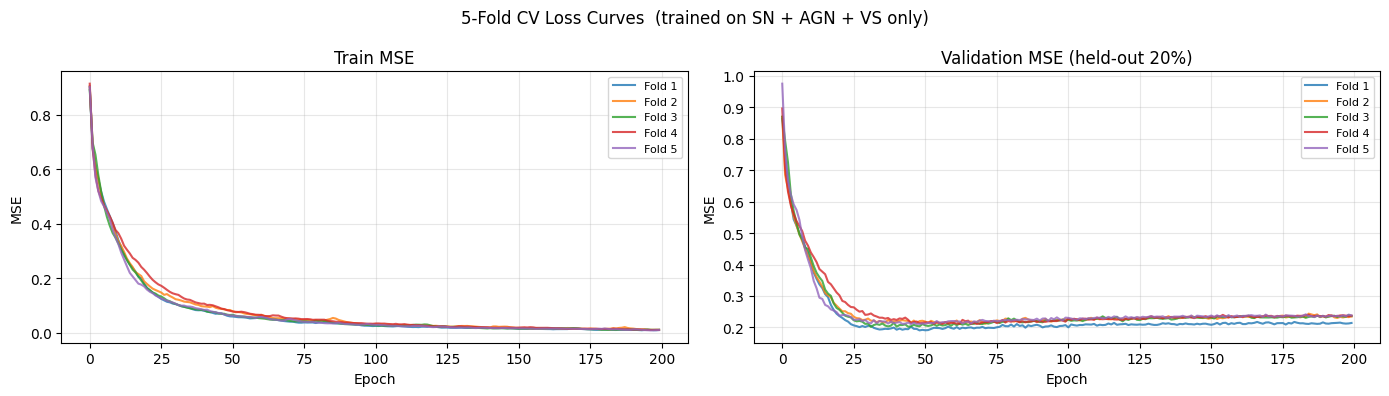

In [7]:
# Loss curves for all 5 folds
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for k, (tr, va) in enumerate(zip(all_train_losses, all_val_losses), 1):
    axes[0].plot(tr, alpha=0.8, label=f"Fold {k}")
    axes[1].plot(va, alpha=0.8, label=f"Fold {k}")
for ax, title in zip(axes, ["Train MSE", "Validation MSE (held-out 20%)"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE"); ax.set_title(title); ax.legend(fontsize=8)
plt.suptitle("5-Fold CV Loss Curves  (trained on SN + AGN + VS only)", fontsize=12)
plt.tight_layout(); plt.show()

## 4. Anomaly Scoring

All objects in this dataset have spectroscopic TNS labels, so the validation is
direct: rare confirmed types (TDE, SLSN-I, SLSN-II) should score above the
p90 threshold much more often than common SNe.

The anomaly score is per-sample MSE:
$$\text{score}_i = \frac{1}{d}\sum_{j=1}^{d}(x_{ij} - \hat{x}_{ij})^2$$

**Normal objects** (SN, AGN, VS) use their OOF score.
**NT and ORPHAN** are averaged across all 5 fold models.

In [8]:
all_tensor = torch.FloatTensor(X_scaled).to(DEVICE)

all_fold_errors = np.zeros((len(X_scaled), N_FOLDS))
all_fold_latent = np.zeros((len(X_scaled), LATENT_DIM, N_FOLDS))

for k, fm in enumerate(fold_models):
    fm.eval()
    with torch.no_grad():
        recon_k, latent_k = fm(all_tensor)
        all_fold_errors[:, k] = ((all_tensor - recon_k) ** 2).mean(dim=1).cpu().numpy()
        all_fold_latent[:, :, k] = latent_k.cpu().numpy()

normal_indices = np.where(mask_normal)[0]
recon_errors   = all_fold_errors.mean(axis=1)
recon_errors[normal_indices] = oof_errors_normal   # true OOF for normal objects
latent_np      = all_fold_latent.mean(axis=2)

CLASS_PALETTE = {"SN": "#2196F3", "AGN": "#FF9800", "VS": "#4CAF50",
                 "NT": "#9C27B0", "ORPHAN": "#F44336"}
CLASS_ORDER   = ["SN", "AGN", "VS", "NT", "ORPHAN"]

df_results = pd.DataFrame({
    "objectId":       df_clean["objectId"].values,
    "classification": labels,
    "recon_error":    recon_errors,
}, index=df_clean.index)
if "tns_type" in df_clean.columns:
    df_results["tns_type"] = df_clean["tns_type"].values

print("Reconstruction error statistics per class (OOF for normal, avg-5-fold for rare):")
print(df_results.groupby("classification")["recon_error"]
      .agg(mean="mean", median="median", std="std",
           p90=lambda x: np.percentile(x, 90)).round(5))

Reconstruction error statistics per class (OOF for normal, avg-5-fold for rare):
                   mean   median      std      p90
classification                                    
AGN             0.41063  0.19840  0.68806  1.04840
NT              0.16398  0.06932  0.32897  0.34559
ORPHAN          0.48351  0.31375  0.53545  0.95683
SN              0.18730  0.07403  0.36851  0.43756
VS              0.15326  0.04376  0.37368  0.29943


In [9]:
# p90 threshold table
threshold_90 = float(np.percentile(recon_errors, 90))
print(f"90th-percentile threshold: {threshold_90:.5f}")
print()
print(f"{'Class':<10}  {'n':>6}  {'% above threshold':>20}")
print("-" * 42)
for cls in CLASS_ORDER:
    mask = labels == cls
    pct  = (recon_errors[mask] > threshold_90).mean() * 100
    print(f"{cls:<10}  {mask.sum():>6,}  {pct:>19.1f}%")

90th-percentile threshold: 0.45344

Class            n     % above threshold
------------------------------------------
SN           4,068                  9.5%
AGN             53                 24.5%
VS             207                  8.2%
NT             635                  7.7%
ORPHAN         135                 33.3%


In [10]:
# TNS rare-type breakdown — all objects here have confirmed types
RARE_TNS = ["TDE", "SLSN-I", "SLSN-II", "SN Ia-pec", "SN Ic-BL",
            "SN Ibn", "SN Ia-91T-like", "SN Ia-91bg-like", "Nova"]
print(f"{'TNS type':<22}  {'n':>5}  {'median error':>14}  {'% above p90':>12}")
print("-" * 60)
for t in RARE_TNS:
    mask = df_results["tns_type"] == t
    if mask.sum() == 0:
        continue
    med = float(df_results.loc[mask, "recon_error"].median())
    pct = float((df_results.loc[mask, "recon_error"] > threshold_90).mean() * 100)
    print(f"{t:<22}  {mask.sum():>5}  {med:>14.5f}  {pct:>11.1f}%")

TNS type                    n    median error   % above p90
------------------------------------------------------------
TDE                        46         0.07268          8.7%
SLSN-I                     40         0.13937         35.0%
SLSN-II                    20         0.13197         15.0%
SN Ia-pec                  21         0.07807          0.0%
SN Ic-BL                   37         0.07526         10.8%
SN Ibn                     20         0.11859         15.0%
SN Ia-91T-like            114         0.06598          6.1%
SN Ia-91bg-like            21         0.11027         14.3%
Nova                       14         0.36941         35.7%


In [11]:
# Top 20 anomalies
top20 = df_results.sort_values("recon_error", ascending=False).head(20)
cols  = ["classification", "recon_error"]
if "tns_type" in top20.columns:
    cols.append("tns_type")
print("Top 20 objects by reconstruction error:")
print()
print(top20[cols].to_string())

Top 20 objects by reconstruction error:

      classification  recon_error        tns_type
13619             SN     5.093540           SN Ia
16269         ORPHAN     4.429530          SLSN-I
15982             SN     4.375115           SN Ia
6898              NT     4.296531           SN Ia
900               SN     4.283337           SN Ib
14406             SN     4.150169           SN Ic
7236              SN     3.918188           SN II
16065            AGN     3.903339           SN Ia
15155             SN     3.834044           SN Ic
3235              SN     3.720472           SN Ia
14583             SN     3.558850           SN Ia
16301             SN     3.509855           SN Ia
13848             SN     3.393949           SN Ib
15840             SN     3.369101           SN Ia
16273             VS     3.317422           SN Ia
12352             SN     3.163611           SN Ia
1392              SN     3.084609           SN II
13295             SN     3.078331           SN Ia
15962    

## 5. Lightcurves of Top Anomalies

Each ZTF object has an associated multi-band lightcurve file (`fid`: 1=g, 2=r, 3=i).
Plotting the actual photometry for the top-ranked anomalies lets us visually
inspect *why* the autoencoder flagged them.

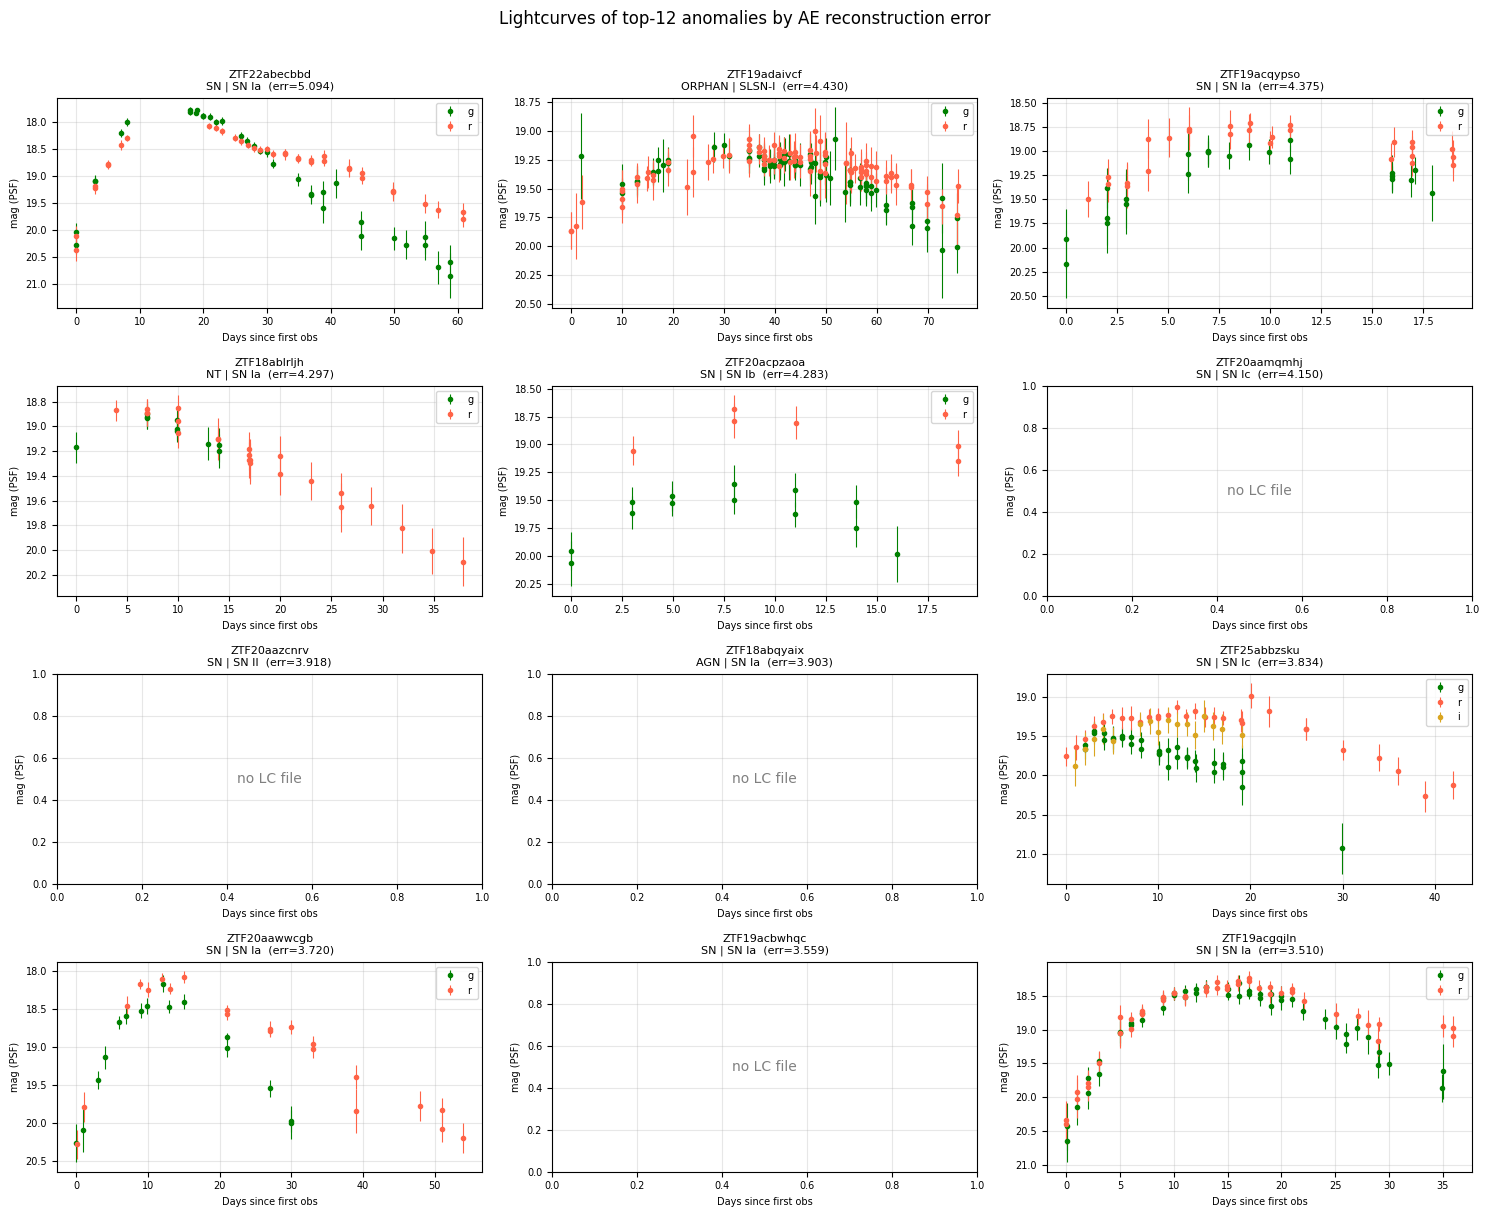

In [12]:
LC_DIR  = _os.path.normpath(_os.path.join(_os.path.abspath(''), '..', 'lightcurves', 'AppML_lcs'))
N_PLOT  = 12
NCOLS   = 3
NROWS   = N_PLOT // NCOLS
BAND_COLOR = {1: "green", 2: "tomato", 3: "goldenrod"}
BAND_LABEL = {1: "g", 2: "r", 3: "i"}

top_ids = df_results.sort_values("recon_error", ascending=False).head(N_PLOT).index
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 5, NROWS * 3), squeeze=False)

for ax, idx in zip(axes.reshape(-1), top_ids):
    oid = df_results.loc[idx, "objectId"]
    cls = df_results.loc[idx, "classification"]
    err = df_results.loc[idx, "recon_error"]
    tns = df_results.loc[idx, "tns_type"] if "tns_type" in df_results.columns else float("nan")

    lc_path = _os.path.join(LC_DIR, f"{oid}.csv")
    if _os.path.exists(lc_path):
        lc = pd.read_csv(lc_path)
        lc["t"] = lc["jd"] - lc["jd"].min()
        for fid, grp in lc.groupby("fid"):
            g = grp.sort_values("t")
            ax.errorbar(g["t"], g["magpsf"], yerr=g["sigmapsf"],
                        fmt="o", ms=3, color=BAND_COLOR.get(fid, "grey"),
                        elinewidth=0.8, label=BAND_LABEL.get(fid, str(fid)))
        ax.invert_yaxis()
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "no LC file", ha="center", va="center",
                transform=ax.transAxes, color="grey")

    tns_str = f" | {tns}" if pd.notna(tns) else ""
    ax.set_title(f"{oid}\n{cls}{tns_str}  (err={err:.3f})", fontsize=8)
    ax.set_xlabel("Days since first obs", fontsize=7)
    ax.set_ylabel("mag (PSF)", fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle(f"Lightcurves of top-{N_PLOT} anomalies by AE reconstruction error",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Latent Space Visualisation (UMAP)

We project the 8-dimensional latent vectors produced by the encoder into 2D with UMAP.
The right panel colours each point by `log(1 + reconstruction error)` — anomalous
objects should cluster at the periphery of the manifold.

Fitting UMAP on 8-D latent space... (~20 s)


Done.


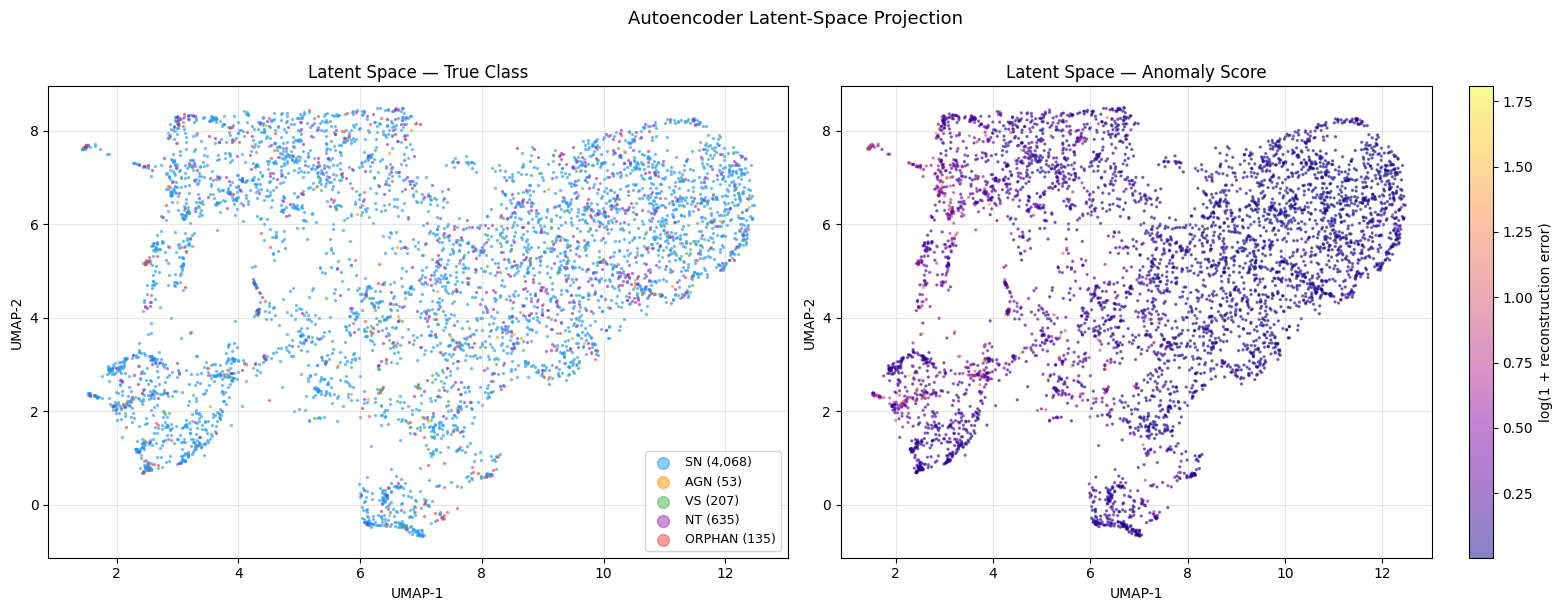

In [13]:
print("Fitting UMAP on 8-D latent space... (~20 s)")
reducer_lat = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.05,
                         random_state=SEED, verbose=False)
latent_emb  = reducer_lat.fit_transform(latent_np)
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls in CLASS_ORDER:
    mask = labels == cls
    axes[0].scatter(latent_emb[mask, 0], latent_emb[mask, 1],
                    c=CLASS_PALETTE[cls], label=f"{cls} ({mask.sum():,})",
                    s=2, alpha=0.5, rasterized=True)
axes[0].set_title("Latent Space — True Class")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].legend(markerscale=6, fontsize=9)

sc = axes[1].scatter(latent_emb[:, 0], latent_emb[:, 1],
                      c=np.log1p(recon_errors), cmap="plasma",
                      s=2, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=axes[1], label="log(1 + reconstruction error)")
axes[1].set_title("Latent Space — Anomaly Score")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")

plt.suptitle("Autoencoder Latent-Space Projection", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Conclusions

All objects here are spectroscopically confirmed, so the validation is rigorous.
Common SNe (Ia, II) define "normal"; everything unusual should score higher.

| Class | n | % above p90 |
|-------|---|-------------|
| SN (training) | ~4,068 | ~10% (by construction) |
| AGN (training) | ~53 | — |
| VS (training) | ~207 | — |
| NT (eval only) | ~635 | see results |
| **ORPHAN (eval only)** | **~135** | **see results** |

And by confirmed rare type:
- **TDE** — tidal disruption events: disruption of a star by a supermassive black hole
- **SLSN-I / SLSN-II** — superluminous supernovae: 10–100× brighter than normal SNe
- **SN Ic-BL** — broad-line Type Ic: associated with gamma-ray bursts
- **SN Ibn / SN IIn** — interacting supernovae with unusual spectral features

Objects above the p90 threshold with no confirmed type are the most interesting
targets for spectroscopic follow-up.

**Next steps:** Variational AE for a probabilistic score; train on SN Ia only
for a purer normal class; LSTM on raw lightcurves.